In [3]:
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

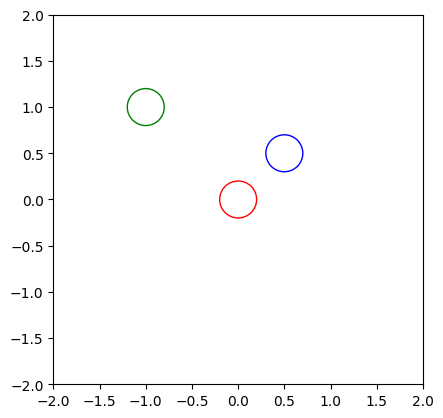

In [5]:
circle1 = plt.Circle((0, 0), 0.2, color='r',fill=False)
circle2 = plt.Circle((0.5, 0.5), 0.2, color='blue',fill=False)
circle3 = plt.Circle((-1, 1), 0.2, color='g' ,fill=False)

fig, ax = plt.subplots() # note we must use plt.subplots, not plt.subplot
# (or if you have an existing figure)
# fig = plt.gcf()
# ax = fig.gca()

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.set_aspect('equal') 

# Set appropriate axis limits
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.show()

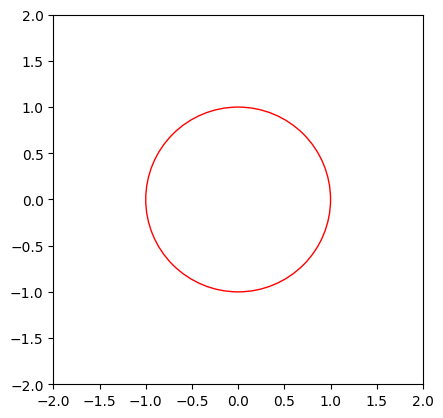

In [6]:
circle1 = plt.Circle((0, 0), 1, color='r',fill=False)

fig, ax = plt.subplots() 
# (or if you have an existing figure)
# fig = plt.gcf()
# ax = fig.gca()

ax.add_patch(circle1)

ax.set_aspect('equal') 

# Set appropriate axis limits
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.show()

In [7]:
def draw_circle(center,radius):

    circle1 = plt.Circle(center, radius, color='r',fill=False)

    fig, ax = plt.subplots() 
    # (or if you have an existing figure)
    # fig = plt.gcf()
    # ax = fig.gca()

    ax.add_patch(circle1)

    ax.set_aspect('equal') 

    # Set appropriate axis limits
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    plt.show()

In [8]:
from shapely.geometry import Point, LineString

# Punt op cirkel checken (via afstand)
center = Point(0, 0)
radius = 5
test_point = Point(3, 4)

# Afstand berekenen
dist = center.distance(test_point)
is_on_circle = abs(dist - radius) < 0.0001 # Tolerantie voor float-fouten

In [49]:
from shapely.geometry import Point, Polygon
import math

def circle_from_3_points(p1, p2, p3):
    """
    Bereken het middelpunt en de straal van een cirkel door 3 punten.
    Returns: (center_x, center_y, radius)
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    
    # Bereken het middelpunt met de formule voor de omgeschreven cirkel
    d = 2 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
    
    if abs(d) < 1e-10:
        raise ValueError("De drie punten liggen op één lijn - geen unieke cirkel mogelijk")
    
    ux = ((x1**2 + y1**2) * (y2 - y3) + 
          (x2**2 + y2**2) * (y3 - y1) + 
          (x3**2 + y3**2) * (y1 - y2)) / d
    
    uy = ((x1**2 + y1**2) * (x3 - x2) + 
          (x2**2 + y2**2) * (x1 - x3) + 
          (x3**2 + y3**2) * (x2 - x1)) / d
    
    center = (ux, uy)
    radius = math.sqrt((x1 - ux)**2 + (y1 - uy)**2)
    
    return center, radius

def bounding_box_from_center_radius(center, radius):
    center_x, center_y = center
    minx = center_x - radius
    miny = center_y - radius
    maxx = center_x + radius
    maxy = center_y + radius

    return (minx,miny), (maxx,maxy)

def calculate_endpoint(p1, angle_degrees, distance):
    """
    Calculate the endpoint p2 given a start point, angle, and distance.
    
    Args:
        p1: Tuple (x1, y1) representing the start point
        angle_degrees: Angle in degrees (0-180), measured from positive x-axis
        distance: Length of the line segment
    
    Returns:
        Tuple (x2, y2) representing the end point
    
    Note:
        - 0° points right (positive x direction)
        - 90° points up (positive y direction)
        - 180° points left (negative x direction)
    """
    x1, y1 = p1
    
    # Convert angle from degrees to radians
    angle_radians = math.radians(angle_degrees)
    
    # Calculate the endpoint using trigonometry
    x2 = x1 + distance * math.cos(angle_radians)
    y2 = y1 + distance * math.sin(angle_radians)
    
    return (x2, y2)

def circle_intersections(c1, r1, c2, r2):
    """
    Calculate the intersection points of two circles.
    
    Args:
        c1: Tuple (x1, y1) - Center of circle 1
        r1: Radius of circle 1
        c2: Tuple (x2, y2) - Center of circle 2
        r2: Radius of circle 2
    
    Returns:
        A list of tuples containing intersection points.
        - Empty list [] if no intersection.
        - One tuple [(x, y)] if tangent.
        - Two tuples [(x, y), (x, y)] if they intersect at two points.
    """
    x1, y1 = c1
    x2, y2 = c2
    
    # Calculate distance between centers
    d = math.hypot(x2 - x1, y2 - y1)
    
    # Check for impossible cases
    # 1. Circles are too far apart
    if d > r1 + r2:
        return []
    # 2. One circle is completely inside the other
    if d < abs(r1 - r2):
        return []
    # 3. Concentric circles with different radii (d=0)
    if d == 0 and r1 != r2:
        return []
    # 4. Concentric circles with same radii (infinite intersections)
    if d == 0 and r1 == r2:
        raise ValueError("Circles are identical; infinite intersection points.")

    # Calculate the distance from c1 to the line connecting the intersection points
    # Using the Law of Cosines derivation
    a = (r1**2 - r2**2 + d**2) / (2 * d)
    
    # Height from the line connecting centers to the intersection points
    h = math.sqrt(max(0, r1**2 - a**2)) # max(0, ...) handles floating point errors
    
    # Coordinates of the point P2 (the point on the line between centers closest to intersections)
    x2_temp = x1 + a * (x2 - x1) / d
    y2_temp = y1 + a * (y2 - y1) / d
    
    # Calculate the two intersection points
    x3_1 = x2_temp + h * (y2 - y1) / d
    y3_1 = y2_temp - h * (x2 - x1) / d
    
    x3_2 = x2_temp - h * (y2 - y1) / d
    y3_2 = y2_temp + h * (x2 - x1) / d
    
    return [(x3_1, y3_1), (x3_2, y3_2)]

def move(p,delta_matrix):
    new_x = p[0] + delta_matrix[0]
    new_y = p[1] + delta_matrix[1]
    return (new_x,new_y)

def rotate_point(p,angle):
    p_new = (
                (p[0]*math.cos(angle)) - (p[1] * math.sin(angle)),
                (p[0]*math.sin(angle)) + (p[1] * math.cos(angle))
            )
    return p_new

def get_angle_counter_clockwise(p):
        x,y = p
        base_angle = 0
        if x == 0 and y > 0:
            return 90
        elif x == 0 and y < 0:
            return 270
        elif x >= 0 and y == 0:
            return 0
        elif x < 0 and y == 0:
            return 180
        else:
            base_angle = math.degrees(math.atan(y/x))
            print(f'base_angle = {base_angle}')

        if x > 0 and y > 0:
            return base_angle
        elif x > 0 and y < 0:
            return base_angle + 360
        elif x  < 0 and y > 0:
            return base_angle + 180
        elif x < 0 and y < 0:
            return base_angle + 180

        
        
def caculate_angle_counter_clockwise(p1,p2,p3):
    # move to new coordinate system with p2 at 0,0
    delta=(-p2[0],-p2[1])
    p1_a = move(p1,delta)
    p3_a = move(p3,delta)

    print(f"p1= {p1} , p2 = {p2} , p3={p3}")
    print(f"p1_a= {p1_a} , p3_a={p3_a}")
    
    angle_1 = get_angle_counter_clockwise(p1_a)
    angle_2 = get_angle_counter_clockwise(p3_a)

    print(f"angle_1= {angle_1} , angle_2 = {angle_2}")
    diff_angle = angle_1 - angle_2
    if diff_angle < 0:
        return diff_angle + 360
    else:
        return diff_angle
    return angle_1 - angle_2

In [39]:
vals = [0,0.5,1,-0.5,-1]
for x in vals:
    for y in vals:
        p = (x,y)
        angle = get_angle_counter_clockwise(p)
        print(f'p={p}, angle={angle}')

p1=(-1,0)
p2=(0,0)
p3=(0,1)
caculate_angle_counter_clockwise(p1,p2,p3)

p=(0, 0), angle=0
p=(0, 0.5), angle=90
p=(0, 1), angle=90
p=(0, -0.5), angle=270
p=(0, -1), angle=270
p=(0.5, 0), angle=0
p=(0.5, 0.5), angle=45.0
p=(0.5, 1), angle=63.43494882292201
p=(0.5, -0.5), angle=315.0
p=(0.5, -1), angle=296.565051177078
p=(1, 0), angle=0
p=(1, 0.5), angle=26.56505117707799
p=(1, 1), angle=45.0
p=(1, -0.5), angle=333.434948822922
p=(1, -1), angle=315.0
p=(-0.5, 0), angle=180
p=(-0.5, 0.5), angle=225.0
p=(-0.5, 1), angle=243.43494882292202
p=(-0.5, -0.5), angle=225.0
p=(-0.5, -1), angle=243.43494882292202
p=(-1, 0), angle=180
p=(-1, 0.5), angle=206.56505117707798
p=(-1, 1), angle=225.0
p=(-1, -0.5), angle=206.56505117707798
p=(-1, -1), angle=225.0
p1= (-1, 0) , p2 = (0, 0) , p3=(0, 1)
p1_a= (-1, 0) , p3_a=(0, 1)
angle_1= 180 , angle_2 = 90


90

In [42]:
p1 = (0,0)
p2 = (0,1)
p2 = (1,0.2)
center, radius = circle_from_3_points(p1,p2,p2)

circle1 = plt.Circle(center, radius, color='r',fill=False)

p1_v = plt.Circle(p1, 0.01, color='r',fill=True)
p2_v = plt.Circle(p2, 0.01, color='b',fill=True)
p3_v = plt.Circle(p2, 0.01, color='g',fill=True)

line_1 = plt.Line2D(p1,p2)
line_2 = plt.Line2D(p2,p2)

fig, ax = plt.subplots() 
# (or if you have an existing figure)
# fig = plt.gcf()
# ax = fig.gca()

ax.add_patch(circle1)
ax.add_patch(p1_v)
ax.add_patch(p2_v)
ax.add_patch(p3_v)
ax.add_line(line_1)
ax.add_line(line_2)

ax.set_aspect('equal') 
ax.annotate('p1', xy = p1, xytext = p1)
ax.annotate('p2', xy = p1, xytext = p1)
ax.annotate('p3', xy = p2, xytext = p2)

# Set appropriate axis limits
bb1,bb2 = bounding_box_from_center_radius(center,radius)
ax.set_xlim(bb1[0], bb2[0])
ax.set_ylim(bb1[1], bb2[1])

plt.show()

ValueError: De drie punten liggen op één lijn - geen unieke cirkel mogelijk

p1= (1, 0) , p2 = (0.8256885145046835, 1.992389396183491) , p3=(1.5444849511191907, 0.6758288458439758)
p1_a= (0.1743114854953165, -1.992389396183491) , p3_a=(0.7187964366145072, -1.3165605503395152)
base_angle = -85.0
base_angle = -61.366989294070486
angle_1= 275.0 , angle_2 = 298.6330107059295
p1= (1, 0) , p2 = (0.8256885145046835, 1.992389396183491) , p3=(-0.518499259085832, 1.3266873387059936)
p1_a= (0.1743114854953165, -1.992389396183491) , p3_a=(-1.3441877735905154, -0.6657020574774974)
base_angle = -85.0
base_angle = 26.346676343145734
angle_1= 275.0 , angle_2 = 206.34667634314573
print: 336.3669892940705
print: 68.65332365685427
p1= (0.8256885145046835, 1.992389396183491) , p2 = (-0.518499259085832, 1.3266873387059936) , p3=(-0.24508525912113954, 1.74530982331869)
p1_a= (1.3441877735905154, 0.6657020574774974) , p3_a=(0.2734139999646925, 0.41862248461269624)
base_angle = 26.346676343145734
base_angle = 56.850328519554914
angle_1= 26.346676343145734 , angle_2 = 56.85032851955491

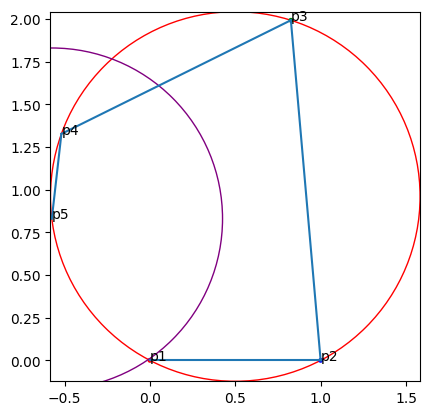

In [62]:
d_1 = 1
d_2 = 2
d_3 = 1.5
d_4 = 0.5
d_5 = 1
angle= 95

p1 = (0,0)
p2 = (d_1,0)

p3 = calculate_endpoint(p2,angle,d_2)
center, radius = circle_from_3_points(p1,p2,p3)

circle1 = plt.Circle(center, radius, color='r',fill=False)


def get_next_point(center,radius,p1,p2,d):
    intersection = circle_intersections(center,radius,p2,d)

    # now choose the point that has an agle between 0 and 180
    angle_1 = caculate_angle_counter_clockwise(p1,p2,intersection[0])
    angle_2 = caculate_angle_counter_clockwise(p1,p2,intersection[1])
    print(f"print: {angle_1}")
    print(f"print: {angle_2}")
    if angle_1 > 0 and angle_1 < 180:
        return intersection[0]
    else:
        return intersection[1]
    
p4 = get_next_point(center,radius,p2,p3,d_3)
p5 = get_next_point(center,radius,p3,p4,d_4)

circle2 = plt.Circle(p5, d_5, color='purple',fill=False)

p1_v = plt.Circle(p1, 0.01, color='r',fill=True)
p2_v = plt.Circle(p2, 0.01, color='b',fill=True)
p3_v = plt.Circle(p3, 0.01, color='g',fill=True)

line_1 = plt.Line2D((p1[0],p2[0]),(p1[1],p2[1]))
line_2 = plt.Line2D((p2[0],p3[0]),(p2[1],p3[1]))
line_3 = plt.Line2D((p3[0],p4[0]),(p3[1],p4[1]))
line_4 = plt.Line2D((p4[0],p5[0]),(p4[1],p5[1]))

fig, ax = plt.subplots() 
# (or if you have an existing figure)
# fig = plt.gcf()
# ax = fig.gca()

ax.add_patch(circle1)
ax.add_patch(p1_v)
ax.add_patch(p2_v)
ax.add_patch(p3_v)
ax.add_line(line_1)
ax.add_line(line_2)
ax.add_line(line_3)
ax.add_line(line_4)
ax.add_patch(circle2)

ax.set_aspect('equal') 
ax.annotate('p1', xy = p1, xytext = p1)
ax.annotate('p2', xy = p2, xytext = p2)
ax.annotate('p3', xy = p3, xytext = p3)
ax.annotate('p4', xy = p4, xytext = p4)
ax.annotate('p5', xy = p5, xytext = p5)


# Set appropriate axis limits
bb1,bb2 = bounding_box_from_center_radius(center,radius)
ax.set_xlim(bb1[0], bb2[0])
ax.set_ylim(bb1[1], bb2[1])

plt.show()